In [ ]:
# RECONHECIMENTO FACIAL E COMPARAÇÃO VETORIAL
# Instalação prévia
!pip install face-recognition opencv-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.1/100.1 MB 7.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for face-recognition-models: filename=face_recognition_models-0.3.0-py2.py3-none-any.whl size=100566166 sha256=d75e263c71ef2c7b4d6ea0af77038cfaa718b4342a2967c7630a13be4eee5681
  Stored in directory: /root/.cache/pip/wheels/39/20/47/6b647a3457f0e36c161b2516a5bd7f29f6bbd5e3a67c46a710
Successfully built face-recognition-models


[SISTEMA] Carregando imagem e gerando vetor de 128 números ...
Distância calculada entre os rostos: 0.7512

--- Resultado da análise de biometria facial ---


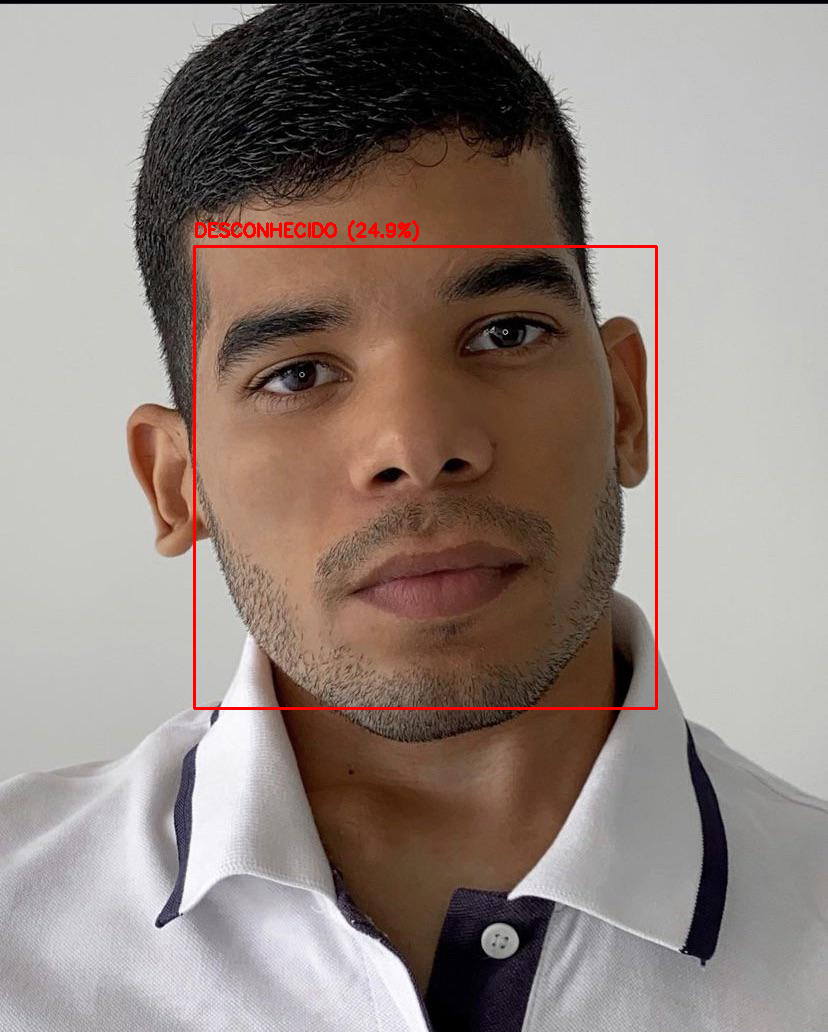

In [ ]:
import cv2
import face_recognition
from google.colab.patches import cv2_imshow

# 1. Carregar a referência (O cadastro no banco de dados)
print("[SISTEMA] Carregando imagem e gerando vetor de 128 números ...")

# 2. A biblioteca carrega o arquivo e calcula a assinatura matemática (encoding)
foto_base = face_recognition.load_image_file("referencia.jpg")
encoding_referencia = face_recognition.face_encodings(foto_base)[0]

# 3. Carregar a foto de teste (tentativa de identificação)
imagem_analise = cv2.imread("teste_desconhecido.jpg")

# 4. Conversão obrigatória: face_recognition lê em RGB, mas o OpenCV lê em BGR
imagem_analise_rgb = cv2.cvtColor(imagem_analise, cv2.COLOR_BGR2RGB)

# 5. Localizar rostos na foto e extrair seus encondings
locais_dos_rostos = face_recognition.face_locations(imagem_analise_rgb)
encodings_dos_rostos = face_recognition.face_encodings(imagem_analise_rgb, locais_dos_rostos)

# 6. Varre todos os rostos encontrados na foto de teste
for (topo, direita, fundo, esquerda), encoding_rosto_atual in \
    zip(locais_dos_rostos, encodings_dos_rostos):

    # Calcular a distância matemática entre as duas assinaturas
    distancia = face_recognition.face_distance([encoding_referencia], encoding_rosto_atual)[0]
    print(f"Distância calculada entre os rostos: {distancia:.4f}")

    # Lógica de Threshold (Limite de tolerância de mercado = 0.6)
    if distancia < 0.6:
        label_texto = f"IDENTIFICADO ({100 - (distancia * 100):.1f}%)"
        cor_borda = (0, 255, 0) # Verde para sucesso
    else:
        label_texto = f"DESCONHECIDO ({100 - (distancia * 100):.1f}%)"
        cor_borda = (0, 0, 255) # Vermelho para falha

    # OpenCV para desenha feedback na tela
    cv2.rectangle(imagem_analise, (esquerda, topo), (direita, fundo), cor_borda, 2)
    cv2.putText(imagem_analise, label_texto, (esquerda, topo - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, cor_borda, 2)

# 7. Exibe o diagnóstico na tela
print("\n--- Resultado da análise de biometria facial ---")
cv2_imshow(imagem_analise)